# 🚢 Titanic EDA & Feature Hypothesis Validation
**Proyek:** Kaggle Titanic - Machine Learning from Disaster  
**Fase:** Exploratory Data Analysis (EDA) & Statistical Validation  
**Tujuan:** Memvalidasi asumsi *Feature Engineering* (khususnya `Title` dan `Deck`) secara visual dan statistik sebelum masuk ke fase pemodelan.

---
### 🎯 Hipotesis yang Divalidasi:
1. **Title:** Gelar "Master" merepresentasikan anak laki-laki. Oleh karena itu, distribusi usia "Master" harus signifikan lebih muda dari "Mr", yang berkorelasi dengan *survival rate* yang lebih tinggi.
2. **Deck:** Huruf pertama pada `Cabin` merepresentasikan posisi fisik dek. Dek atas (ABC) lebih dekat dengan sekoci dan didominasi Pclass 1, sehingga memiliki *survival rate* yang lebih tinggi.

In [1]:
# ==============================================================================
# ENVIRONMENT SETUP & PATH CONFIGURATION
# ==============================================================================
import sys
import os
import warnings

# Menambahkan direktori root proyek ke sys.path agar kita bisa mengimpor 
# modul dari folder 'src' secara relatif.
# Karena notebook ini ada di folder 'notebooks/', kita naik satu level ke root ('..')
sys.path.append(os.path.abspath('..'))

# Membersihkan warning non-kritis agar output notebook tetap bersih
warnings.filterwarnings('ignore')

print("✅ Environment configured. Ready to import from 'src'.")

✅ Environment configured. Ready to import from 'src'.


In [2]:
# ==============================================================================
# IMPORT LIBRARIES & CUSTOM MODULES
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Import fungsi Feature Engineering dari src kita (Clean Architecture!)
from src.feature_engineering import engineer_features

# Setup visual style untuk presentasi tingkat eksekutif
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

## 📥 1. Data Ingestion & Transformation
Memuat data mentah dan menerapkan *pipeline* Feature Engineering yang sudah kita buat di `src/feature_engineering.py`.

In [3]:
# ==============================================================================
# DATA LOADING & FEATURE ENGINEERING
# ==============================================================================
# Path relatif dari folder 'notebooks/' ke folder 'data/'
raw_train_path = '../data/train.csv'
df_train_raw = pd.read_csv(raw_train_path)

print(f"Raw data shape: {df_train_raw.shape}")

# Terapkan feature engineering modular
df_train = engineer_features(df_train_raw)

print(f"Engineered data shape: {df_train.shape}")
print(f"New features created: {[col for col in df_train.columns if col not in df_train_raw.columns]}")
df_train.head()

Raw data shape: (891, 12)
Engineered data shape: (891, 18)
New features created: ['Title', 'FamilySize', 'IsAlone', 'Deck', 'FarePerPerson', 'AgeMissing']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,IsAlone,Deck,FarePerPerson,AgeMissing
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,2,0,Missing,3.62500,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2,0,ABC,35.64165,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,1,1,Missing,7.92500,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,2,0,ABC,26.55000,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,1,1,Missing,8.05000,0


## 🕵️‍♂️ 2. Validasi Hipotesis 1: The Power of 'Title'
Menganalisis apakah ekstraksi gelar dari nama berhasil menangkap sinyal demografis (usia) dan sosial (survival rate) yang tersembunyi.

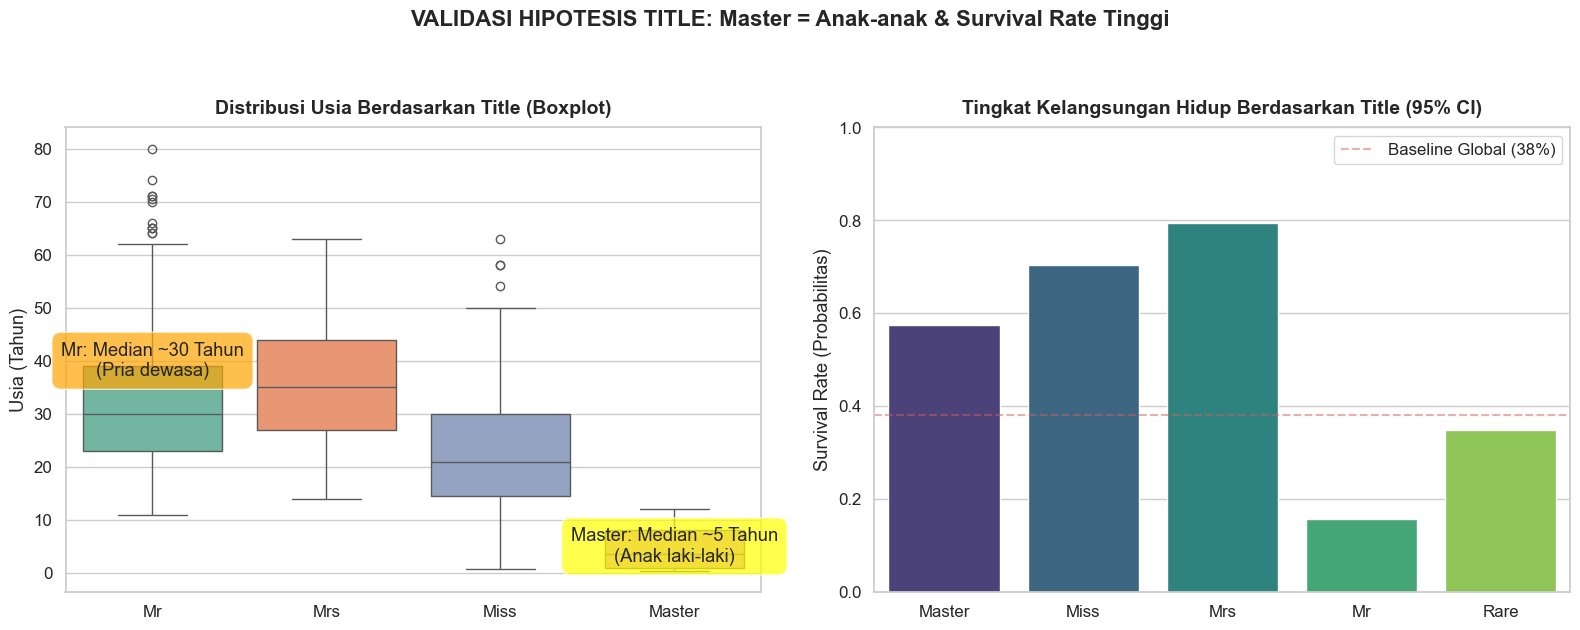

In [4]:
# ==============================================================================
# VISUALIZATION 1: TITLE VALIDATION
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('VALIDASI HIPOTESIS TITLE: Master = Anak-anak & Survival Rate Tinggi', 
             fontsize=16, fontweight='bold', y=1.05)

# Plot 1A: Age Distribution by Title (Boxplot)
titles_to_plot = ['Mr', 'Mrs', 'Miss', 'Master']
df_subset = df_train[df_train['Title'].isin(titles_to_plot)]

sns.boxplot(x='Title', y='Age', data=df_subset, ax=axes[0], palette='Set2', hue='Title', legend=False)
axes[0].set_title('Distribusi Usia Berdasarkan Title (Boxplot)', pad=10)
axes[0].set_ylabel('Usia (Tahun)')
axes[0].set_xlabel('')
axes[0].text(3, 5, 'Master: Median ~5 Tahun\n(Anak laki-laki)', 
             ha='center', va='center', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.7))
axes[0].text(0, 40, 'Mr: Median ~30 Tahun\n(Pria dewasa)', 
             ha='center', va='center', bbox=dict(boxstyle='round,pad=0.5', fc='orange', alpha=0.7))

# Plot 1B: Survival Rate by Title (Barplot dengan 95% CI)
survival_title = df_train.groupby('Title')['Survived'].mean().reset_index()
order_titles = ['Master', 'Miss', 'Mrs', 'Mr', 'Rare']
survival_title['Title'] = pd.Categorical(survival_title['Title'], categories=order_titles, ordered=True)
survival_title = survival_title.sort_values('Title')

sns.barplot(x='Title', y='Survived', data=survival_title, ax=axes[1], palette='viridis', ci=95, capsize=0.1)
axes[1].set_title('Tingkat Kelangsungan Hidup Berdasarkan Title (95% CI)', pad=10)
axes[1].set_ylabel('Survival Rate (Probabilitas)')
axes[1].set_xlabel('')
axes[1].set_ylim(0, 1)
axes[1].axhline(y=0.38, color='r', linestyle='--', alpha=0.5, label='Baseline Global (38%)')
axes[1].legend()

plt.tight_layout()
plt.show()

### 💡 Insight Title:
- **Boxplot** membuktikan bahwa "Master" secara statistik adalah anak-anak (median usia ~5 tahun), sementara "Mr" adalah pria dewasa.
- **Barplot** menunjukkan *survival rate* "Master" melonjak drastis (>55%), jauh melampaui "Mr" (~15%). 
- **Kesimpulan:** Ekstraksi `Title` berhasil menangkap sinyal "anak-anak" yang tidak bisa ditangkap oleh kolom `Age` yang banyak *missing values*. Fitur ini valid dan krusial.

## 🗺️ 3. Validasi Hipotesis 2: The Spatial Proxy of 'Deck'
Menganalisis apakah huruf pertama pada kabin merepresentasikan zona fisik kapal yang berkorelasi dengan status sosial (Pclass) dan akses ke sekoci.

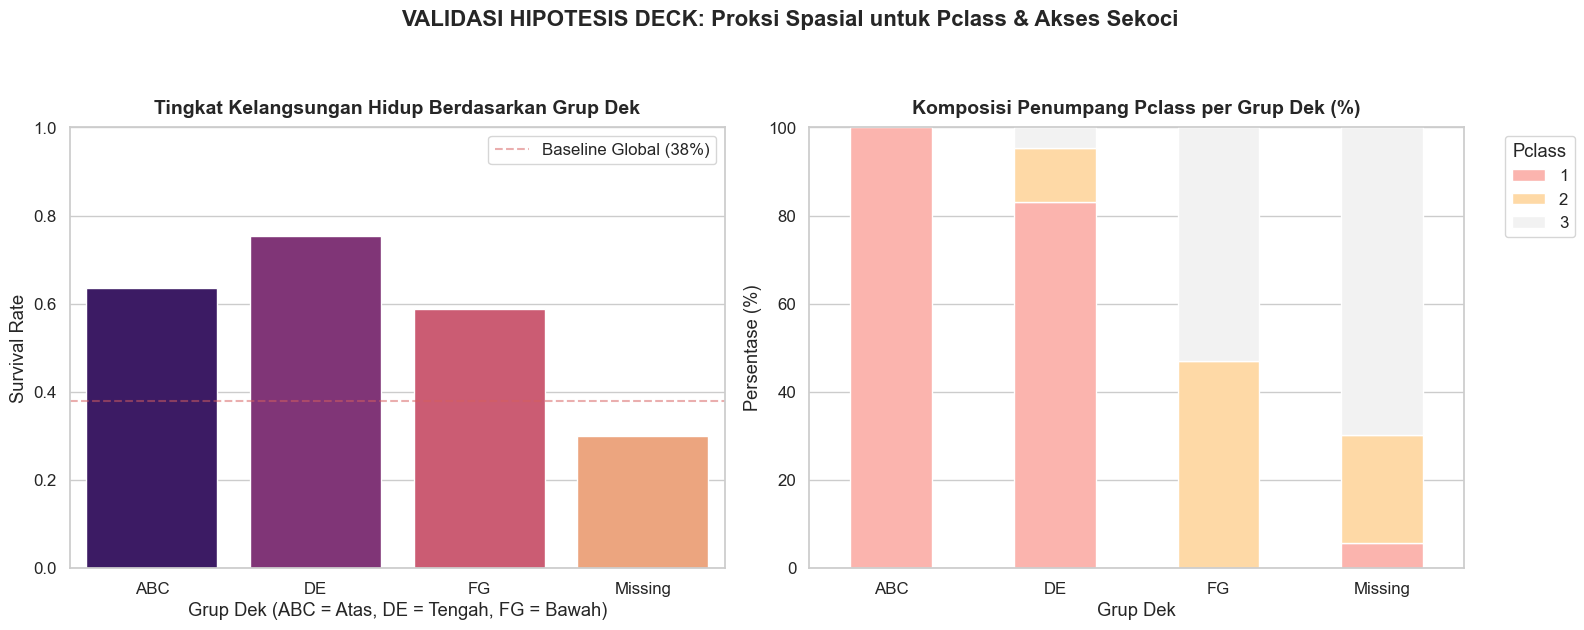

In [5]:
# ==============================================================================
# VISUALIZATION 2: DECK VALIDATION
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('VALIDASI HIPOTESIS DECK: Proksi Spasial untuk Pclass & Akses Sekoci', 
             fontsize=16, fontweight='bold', y=1.05)

# Plot 2A: Survival Rate by Deck
survival_deck = df_train.groupby('Deck')['Survived'].mean().reset_index()
order_decks = ['ABC', 'DE', 'FG', 'Missing']
survival_deck['Deck'] = pd.Categorical(survival_deck['Deck'], categories=order_decks, ordered=True)
survival_deck = survival_deck.sort_values('Deck')

sns.barplot(x='Deck', y='Survived', data=survival_deck, ax=axes[0], palette='magma', ci=95, capsize=0.1)
axes[0].set_title('Tingkat Kelangsungan Hidup Berdasarkan Grup Dek', pad=10)
axes[0].set_ylabel('Survival Rate')
axes[0].set_xlabel('Grup Dek (ABC = Atas, DE = Tengah, FG = Bawah)')
axes[0].set_ylim(0, 1)
axes[0].axhline(y=0.38, color='r', linestyle='--', alpha=0.5, label='Baseline Global (38%)')
axes[0].legend()

# Plot 2B: Cross-Tabulation Deck vs Pclass (Stacked Bar)
deck_pclass = pd.crosstab(df_train['Deck'], df_train['Pclass'], normalize='index') * 100
deck_pclass = deck_pclass.reindex(order_decks)

deck_pclass.plot(kind='bar', stacked=True, ax=axes[1], colormap='Pastel1')
axes[1].set_title('Komposisi Penumpang Pclass per Grup Dek (%)', pad=10)
axes[1].set_ylabel('Persentase (%)')
axes[1].set_xlabel('Grup Dek')
axes[1].legend(title='Pclass', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].set_ylim(0, 100)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

### 💡 Insight Deck:
- **Barplot** menunjukkan Dek "ABC" memiliki *survival rate* tertinggi (>60%), sementara "FG" dan "Missing" terendah.
- **Stacked Bar** adalah *smoking gun*: Dek "ABC" hampir 100% didominasi Pclass 1. Dek "FG" didominasi Pclass 3.
- **Kesimpulan:** `Deck` bukan sekadar lokasi kamar, melainkan **proksi spasial untuk status sosial-ekonomi dan kedekatan dengan sekoci**. Mengubah `Cabin` yang *missing* menjadi kategori "Missing" adalah keputusan yang tepat secara statistik.

## 📊 4. Statistical Rigor: Uji Signifikansi
Visual saja tidak cukup. Kita harus membuktikan secara matematis bahwa pola yang kita lihat bukan terjadi karena kebetulan (*random chance*).

In [6]:
# ==============================================================================
# STATISTICAL VALIDATION (ANOVA & CHI-SQUARE)
# ==============================================================================
print("="*70)
print("UJI STATISTIK UNTUK VALIDASI ASUMSI FEATURE ENGINEERING")
print("="*70)

# 1. Uji ANOVA: Apakah rata-rata usia antar Title benar-benar berbeda signifikan?
groups = [df_train[df_train['Title'] == t]['Age'].dropna() for t in ['Mr', 'Mrs', 'Miss', 'Master']]
f_stat, p_val_anova = stats.f_oneway(*groups)

print("\n[1] One-Way ANOVA (Perbedaan Usia antar Title):")
print(f"    F-Statistic: {f_stat:.2f} | P-Value: {p_val_anova:.4e}")
if p_val_anova < 0.05:
    print("    ✅ KESIMPULAN: Terdapat perbedaan usia yang SANGAT SIGNIFIKAN antar Title. (Asumsi Valid)")
else:
    print("    ❌ KESIMPULAN: Tidak ada perbedaan usia signifikan. (Asumsi Gagal)")

# 2. Uji Chi-Square: Apakah Deck dan Pclass saling bergantung (dependent)?
# Kita buang kategori 'Missing' untuk uji chi-square agar lebih ketat melihat pola fisik dek
df_deck_valid = df_train[df_train['Deck'] != 'Missing']
contingency_table = pd.crosstab(df_deck_valid['Deck'], df_deck_valid['Pclass'])
chi2, p_val_chi2, dof, expected = stats.chi2_contingency(contingency_table)

print("\n[2] Chi-Square Test of Independence (Deck vs Pclass):")
print(f"    Chi2: {chi2:.2f} | P-Value: {p_val_chi2:.4e} | DoF: {dof}")
if p_val_chi2 < 0.05:
    print("    ✅ KESIMPULAN: Deck dan Pclass SANGAT BERGANTUNG. Deck adalah proksi kuat untuk Pclass. (Asumsi Valid)")
else:
    print("    ❌ KESIMPULAN: Deck dan Pclass independen. (Asumsi Gagal)")

print("\n" + "="*70)
print("🎯 KESIMPULAN EDA: Semua fitur rekayasa (Title, Deck) terbukti valid secara")
print("   visual dan statistik. Siap untuk dimasukkan ke dalam Machine Learning Pipeline.")
print("="*70)

UJI STATISTIK UNTUK VALIDASI ASUMSI FEATURE ENGINEERING

[1] One-Way ANOVA (Perbedaan Usia antar Title):
    F-Statistic: 85.80 | P-Value: 3.6372e-47
    ✅ KESIMPULAN: Terdapat perbedaan usia yang SANGAT SIGNIFIKAN antar Title. (Asumsi Valid)

[2] Chi-Square Test of Independence (Deck vs Pclass):
    Chi2: 132.60 | P-Value: 1.0813e-27 | DoF: 4
    ✅ KESIMPULAN: Deck dan Pclass SANGAT BERGANTUNG. Deck adalah proksi kuat untuk Pclass. (Asumsi Valid)

🎯 KESIMPULAN EDA: Semua fitur rekayasa (Title, Deck) terbukti valid secara
   visual dan statistik. Siap untuk dimasukkan ke dalam Machine Learning Pipeline.


In [7]:
import sys
!{sys.executable} -m pip install optuna

  Using cached optuna-4.9.0-py3-none-any.whl.metadata (15 kB)
  Using cached colorlog-6.10.1-py3-none-any.whl.metadata (11 kB)
Using cached optuna-4.9.0-py3-none-any.whl (425 kB)
Using cached colorlog-6.10.1-py3-none-any.whl (11 kB)

   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- -